# 2) Feature selection

Reads `artifacts/windows.npz` (produced by the exploration notebook). 


Steps of feature-engineering: 
 
1. extract a broad set of candidate features per window
2. **split grouped by recording** (never by window)
3. filters: variance threshold, correlation, Fisher scatter score, mutual information
4. wrapper: greedy forward selection on cross-validated error rate
5. extraction: PCA
6. summary


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import LeaveOneGroupOut

PROC_DIR = Path("./../artifacts")
FIG_DIR = Path("./../figures")

z = np.load(PROC_DIR / "windows.npz")
X_raw, CHANNELS, FS = z["X"], list(z["channels"]), int(z["fs"])
meta = pd.read_csv(PROC_DIR / "windows_meta.csv")
y = (meta["label"] == "bumpy").to_numpy().astype(int)      # 1 = bumpy, 0 = smooth

print(f"X_raw {X_raw.shape}, channels {CHANNELS}, {FS} Hz, {y.sum()} bumpy / {(1 - y).sum()} smooth windows")

CLASSES = ["bumpy", "smooth"]
CLASS_COLOR = {"bumpy": "#eb6834", "smooth": "#2a78d6"}
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a"]
plt.rcParams.update(
    {"axes.grid": True, "grid.color": "#e1e0d9",
     "axes.spines.top": False, "axes.spines.right": False,
     "lines.linewidth": 1.0, "figure.dpi": 100})

X_raw (768, 400, 5), channels [np.str_('acc_vertical'), np.str_('acc_vertical_filtered'), np.str_('acc_horizontal'), np.str_('gyro_mag'), np.str_('tacc_mag')], 100 Hz, 395 bumpy / 373 smooth windows


## 2.1 Common Features Extraction

Per window and channel: time-domain statistics

In [2]:
BANDS = [(0.5, 3), (3, 8), (8, 15), (15, 30), (30, 50)]

# 8 temporal statistical features 
def time_feats(x, name):
    x = x - x.mean();       #Zero-Mean Normalization
    s = x.std() + 1e-12 
    
    return {f"{name}_std": x.std(), f"{name}_iqr": np.subtract(*np.percentile(x, [75, 25])), f"{name}_p2p": np.ptp(x),
            f"{name}_p95abs": np.percentile(np.abs(x), 95), f"{name}_madiff": np.abs(np.diff(x)).mean(),
            f"{name}_kurt": ((x / s) ** 4).mean(), f"{name}_skew": ((x / s) ** 3).mean(),
            f"{name}_zcr": (np.diff(np.sign(x)) != 0).mean()}

def spec_feats(x, name):
    w = np.hanning(len(x))
    P = np.abs(np.fft.rfft((x - x.mean()) * w)) ** 2
    f = np.fft.rfftfreq(len(x), 1 / FS)
    
    tot = P[f >= 0.5].sum() + 1e-12
    out = {}
    
    for lo, hi in BANDS:
        out[f"{name}_bp{lo}-{hi}"] = P[(f >= lo) & (f < hi)].sum()           # absolute band power
        out[f"{name}_bf{lo}-{hi}"] = out[f"{name}_bp{lo}-{hi}"] / tot        # fraction of total
        
    p = P[f >= 0.5] / tot
    out[f"{name}_centroid"] = (f[f >= 0.5] * p).sum()
    out[f"{name}_domfreq"] = f[f >= 0.5][p.argmax()]
    out[f"{name}_spec_entropy"] = -(p[p > 0] * np.log(p[p > 0])).sum()
    return out

def extract_features(w):
    """w: one window (samples, channels) in CHANNELS order -> dict of features."""
    ch = {c: w[:, i] for i, c in enumerate(CHANNELS)}
    return (time_feats(ch["acc_vertical"], "vert") 
            | time_feats(ch["acc_vertical_filtered"], "vertbp") | time_feats(ch["acc_horizontal"], "horiz")
            | time_feats(ch["gyro_mag"], "gyro") | time_feats(ch["tacc_mag"], "tacc")
            | spec_feats(ch["acc_vertical"], "vert") | spec_feats(ch["gyro_mag"], "gyro"))

feat = pd.DataFrame([extract_features(w) for w in X_raw])
FEATS = list(feat.columns)
X = feat.to_numpy(float)

print(f"{len(FEATS)} candidate features for {len(feat)} windows")
feat.describe().T.round(3).head(12)

66 candidate features for 768 windows


,count,mean,std,min,25%,50%,75%,max
vert_std,768.0,2.274,0.981,0.503,1.513,2.238,2.866,5.218
vert_iqr,768.0,2.885,1.240,0.612,2.051,2.835,3.683,6.450
vert_p2p,768.0,13.791,7.335,2.937,8.679,12.683,17.461,45.429
vert_p95abs,768.0,4.457,1.937,0.939,2.969,4.361,5.535,10.543
vert_madiff,768.0,0.667,0.332,0.190,0.360,0.629,0.912,1.915
vert_kurt,768.0,3.812,3.009,1.947,2.756,3.153,3.951,54.986
vert_skew,768.0,0.008,0.578,-1.572,-0.386,-0.021,0.319,3.777
vert_zcr,768.0,0.118,0.048,0.018,0.080,0.118,0.155,0.268
vertbp_std,768.0,1.677,0.917,0.391,0.857,1.537,2.336,4.410
vertbp_iqr,768.0,2.042,1.099,0.497,1.016,1.878,2.949,5.369


## 2.2 Data Splitting: 

Cross-validation splitting strategy where we keep in mind that time windows from same measurements should not be combined. Since this would result in data set leakage. 

A fold is a subset where we isolate it to prevent data leakage during training.

In [3]:
N_FOLDS = 4

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=0)
y_composite = meta["participant"].astype(str) + "_" + meta["label"]
fold_of_window = np.zeros(len(meta), dtype=int)

for fold_idx, (train_idx, test_idx) in enumerate(sgkf.split(X=meta, y=y_composite, groups=meta["recording_id"])):
    fold_of_window[test_idx] = fold_idx

# Assign back to your dataset
meta["fold"] = fold_of_window

print("windows per fold and class:")
display(pd.crosstab(meta["fold"], meta["label"]))

windows per fold and class:


label,bumpy,smooth
fold,,
0,78,112
1,117,71
2,115,84
3,85,106


In [4]:
# split iterators: each yields (train_mask, test_mask) over windows
def grouped_splits():
    for k in range(N_FOLDS):
        yield fold_of_window != k, fold_of_window == k

def lopo_splits():
    for p in np.unique(part_of_window):
        yield part_of_window != p, part_of_window == p

# sanity check: no recording appears in both train and test of any grouped fold
for tr, te in grouped_splits():
    assert not set(meta.loc[tr, "recording_id"]) & set(meta.loc[te, "recording_id"])
    
print("grouped folds are leak-free at the recording level")

grouped folds are leak-free at the recording level


## 2.3 Filtering of Feature Selection

1. Variance threshold: Drop constant features (like dead sensors we discussed in lecture)
2. Correlation drop: Of every pair keep one with r > 0.95, the other one does not have new information
3. Relevance score: Fisher scatter score, $(m_1-m_0)^2/(s_1^2+s_0^2)$

In [5]:
# Variance threshold
var = feat.var()
dead = var[var < 1e-10].index.tolist()
kept = [f for f in FEATS if f not in dead]
print(f"[variance] removed {len(dead)}: {dead}")

# 2. correlation pruning (label-free). Of a redundant pair keep the feature from the preferred channel:
#    the band-passed vertical channel was designed for this task, gyro is the least informative.

R_THR = 0.95
PRIORITY = ["vertbp", "vert", "tacc", "horiz", "gyro"]
prio = lambda f: (PRIORITY.index(f.split("_")[0]), f)
C = feat[kept].corr().abs()
pairs = sorted(((C.loc[a, b], a, b) for i, a in enumerate(kept) for b in kept[i + 1:] if C.loc[a, b] > R_THR), reverse=True)

for r, a, b in pairs:
    if a in kept and b in kept:
        kept.remove(max(a, b, key=prio))
removed = [f for f in FEATS if f not in kept and f not in dead]

print(f"[correlation] {len(pairs)} pairs with |r| > {R_THR}: {len(removed)} features removed, {len(kept)} left")
print(f"               removed: {removed}")

[variance] removed 0: []
[correlation] 22 pairs with |r| > 0.95: 14 features removed, 52 left
               removed: ['vert_std', 'vert_p2p', 'vert_madiff', 'vertbp_std', 'horiz_std', 'gyro_std', 'tacc_std', 'tacc_iqr', 'tacc_p2p', 'tacc_p95abs', 'tacc_madiff', 'tacc_kurt', 'tacc_skew', 'tacc_zcr']


## 2.4 PCA of top Features 

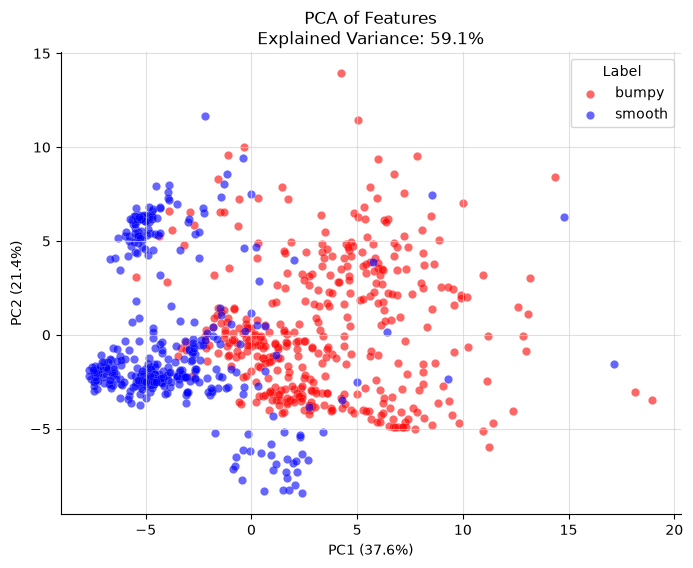

In [6]:
mask_bumpy = meta['label'] == 'bumpy'
mask_smooth = meta['label'] == 'smooth'

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X_pca[mask_bumpy, 0], X_pca[mask_bumpy, 1], 
           c='red', label='bumpy', alpha=0.6, edgecolors='w', linewidth=0.15)

ax.scatter(X_pca[mask_smooth, 0], X_pca[mask_smooth, 1], 
           c='blue', label='smooth', alpha=0.6, edgecolors='w', linewidth=0.15)

# Formatting
ax.set_title(f"PCA of Features\nExplained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(title='Label')
ax.grid(True, color='lightgray', alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('./../figures/PCA_features.png')
plt.show()

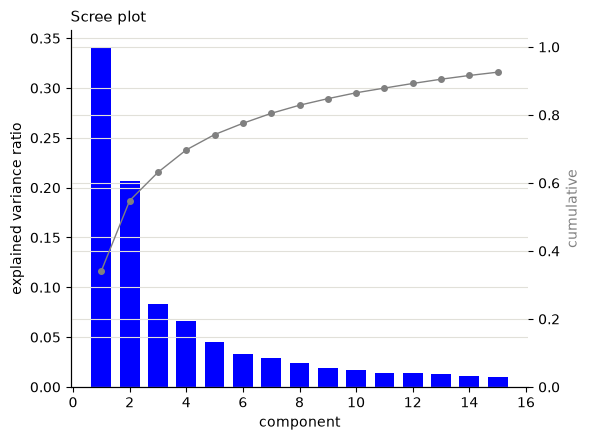

In [7]:
idx = [FEATS.index(c) for c in kept]
Zall = (X[:, idx] - X[:, idx].mean(0)) / (X[:, idx].std(0) + 1e-9)

# Compute eigenvalues to get the explained variance
ev, _ = np.linalg.eigh(np.cov(Zall.T))
order = ev.argsort()[::-1]
ev = ev[order]
ratio = ev / ev.sum()

# Scree Plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Plot individual explained variance (bars)
ax.bar(range(1, 16), ratio[:15], color="blue", width=0.7)
ax.set_xlabel("component")
ax.set_ylabel("explained variance ratio")
ax.set_title("Scree plot", loc="left", fontsize=11)
ax.grid(axis="x", visible=False)
ax.spines['top'].set_visible(False)

# Plot cumulative explained variance (line)
ax2 = ax.twinx()
ax2.plot(range(1, 16), np.cumsum(ratio[:15]), color="gray", marker="o", markersize=4)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("cumulative", color="gray")
ax2.spines['top'].set_visible(False)

fig.tight_layout()
plt.show()

- Mean Fisher score: Ranking metric, where higher number implies that the two classes have different noticeable average values. 
- MI_bits: Mutual information, the closer to 1 the more certain of the difference we are
- Fisher min fold: Lowest fisher score aross any of training folds. Worst-case scenario check
- Stability: Counts how many times the feature actually was in this rank across the folds

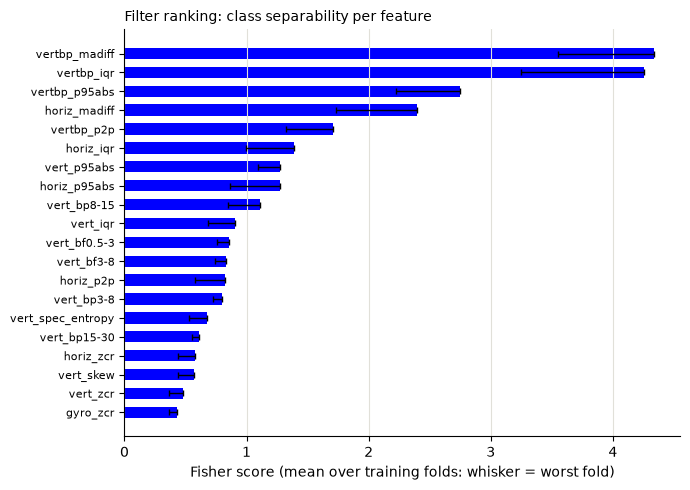

,fisher,MI_bits,fisher_min_fold,stability
feature,,,,
vertbp_madiff,4.333,0.739,3.550,4
vertbp_iqr,4.254,0.717,3.251,4
vertbp_p95abs,2.751,0.633,2.223,4
horiz_madiff,2.394,0.611,1.734,4
vertbp_p2p,1.704,0.540,1.322,4
horiz_iqr,1.392,0.427,0.998,4
vert_p95abs,1.275,0.383,1.096,4
horiz_p95abs,1.274,0.465,0.865,4
vert_bp8-15,1.113,0.611,0.847,4


In [8]:
# 3. relevance, computed on training folds only
def fisher(x, y):
    return (x[y == 1].mean() - x[y == 0].mean()) ** 2 / (x[y == 1].var() + x[y == 0].var() + 1e-12)

def mutual_info(x, y, bins=10):
    edges = np.quantile(x, np.linspace(0, 1, bins + 1))
    xb = np.clip(np.searchsorted(edges, x, side="right") - 1, 0, bins - 1)
    pxy = np.histogram2d(xb, y, bins=[bins, 2])[0] / len(x)
    px, py = pxy.sum(1, keepdims=True), pxy.sum(0, keepdims=True)
    nz = pxy > 0
    return (pxy[nz] * np.log2(pxy[nz] / (px @ py)[nz])).sum()        # bits: label entropy is ~1 bit

rows = []
for k, (tr, _) in enumerate(grouped_splits()):
    for f in kept:
        rows.append({"fold": k, "feature": f, "fisher": fisher(X[tr][:, FEATS.index(f)], y[tr]),
                     "MI_bits": mutual_info(X[tr][:, FEATS.index(f)], y[tr])})
        
rel = pd.DataFrame(rows)
top10_per_fold = rel.groupby("fold").apply(lambda d: set(d.nlargest(10, "fisher")["feature"]), include_groups=False)
scores = rel.groupby("feature")[["fisher", "MI_bits"]].mean()
scores["fisher_min_fold"] = rel.groupby("feature")["fisher"].min()
scores["stability"] = [sum(f in s for s in top10_per_fold) for f in scores.index]
scores = scores.sort_values("fisher", ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
top = scores.head(20)

ax.barh(range(len(top))[::-1], top["fisher"], color="blue", height=0.6)
ax.errorbar(top["fisher"], range(len(top))[::-1], xerr=[top["fisher"] - top["fisher_min_fold"], np.zeros(len(top))],
            fmt="none", ecolor="black", elinewidth=1, capsize=2)

ax.set_yticks(range(len(top))[::-1], top.index, fontsize=8); ax.set_xlabel("Fisher score (mean over training folds: whisker = worst fold)")
ax.set_title("Filter ranking: class separability per feature", loc="left", fontsize=10); ax.grid(axis="y", visible=False)

fig.tight_layout(); fig.savefig(FIG_DIR / "feature_fisher.png", dpi=120, bbox_inches="tight"); plt.show()

scores.head(15).round(3)

## 2.5 Export

- `features.csv`: one row per window with metadata, `fold` and all candidate features
- `feature_scores.csv`: Fisher, MI, worst-fold Fisher and stability per kept feature
- `feature_selection.json`: feature lists from each filter step

In [9]:
out = pd.concat([meta.reset_index(drop=True), feat.reset_index(drop=True)], axis=1)
assert len(out) == len(X_raw) and (out["label"] == np.where(y == 1, "bumpy", "smooth")).all()
out.to_csv(PROC_DIR / "features.csv", index=False)

scores.rename_axis("feature").to_csv(PROC_DIR / "feature_scores.csv")

selection = {"n_windows": len(out), "n_folds": N_FOLDS, "corr_threshold": R_THR,
             "all": FEATS, "variance_removed": dead, "correlation_removed": removed,
             "kept": kept, "ranked_by_fisher": scores.index.tolist()}
(PROC_DIR / "feature_selection.json").write_text(json.dumps(selection, indent=2))

print(f"features.csv            {out.shape}")
print(f"feature_scores.csv      {scores.shape}")
print(f"feature_selection.json  {len(kept)} kept of {len(FEATS)}")

features.csv            (768, 72)
feature_scores.csv      (52, 4)
feature_selection.json  52 kept of 66
